In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [3]:
df = pd.read_csv('/PyAi/dc Stress Level.csv')
df.head()

,ID,Age,StudyHours,SleepHours,ScreenTime,CaffeineCups,RandomNote,StressLevel
0,1,20,5.0,7.0,4.0,2.0,noteA,Low
1,2,21,6.0,6.0,5.0,3.0,noteB,Medium
2,3,19,8.0,5.0,7.0,4.0,noteC,High
3,4,22,2.0,8.0,3.0,1.0,noteD,Low
4,5,20,7.0,6.0,6.0,3.0,noteE,Medium


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   ID            30 non-null     int64  
 1   Age           30 non-null     int64  
 2   StudyHours    29 non-null     float64
 3   SleepHours    29 non-null     float64
 4   ScreenTime    29 non-null     float64
 5   CaffeineCups  29 non-null     float64
 6   RandomNote    30 non-null     str    
 7   StressLevel   30 non-null     str    
dtypes: float64(4), int64(2), str(2)
memory usage: 2.0 KB


In [5]:
df.drop(columns=['ID']).duplicated().sum()

np.int64(1)

In [6]:
df.drop_duplicates()

,ID,Age,StudyHours,SleepHours,ScreenTime,CaffeineCups,RandomNote,StressLevel
0,1,20,5.0,7.0,4.0,2.0,noteA,Low
1,2,21,6.0,6.0,5.0,3.0,noteB,Medium
2,3,19,8.0,5.0,7.0,4.0,noteC,High
3,4,22,2.0,8.0,3.0,1.0,noteD,Low
4,5,20,7.0,6.0,6.0,3.0,noteE,Medium
5,6,23,9.0,4.0,8.0,5.0,noteF,High
6,7,21,4.0,7.0,4.0,2.0,noteG,Low
7,8,22,6.0,6.0,5.0,3.0,noteH,Medium
8,9,20,10.0,3.0,9.0,6.0,noteI,High
9,10,19,3.0,8.0,3.0,1.0,noteJ,Low


In [7]:
df.drop(columns=['ID','RandomNote'])
df.head()

,ID,Age,StudyHours,SleepHours,ScreenTime,CaffeineCups,RandomNote,StressLevel
0,1,20,5.0,7.0,4.0,2.0,noteA,Low
1,2,21,6.0,6.0,5.0,3.0,noteB,Medium
2,3,19,8.0,5.0,7.0,4.0,noteC,High
3,4,22,2.0,8.0,3.0,1.0,noteD,Low
4,5,20,7.0,6.0,6.0,3.0,noteE,Medium


In [8]:
df.isnull().sum()

ID              0
Age             0
StudyHours      1
SleepHours      1
ScreenTime      1
CaffeineCups    1
RandomNote      0
StressLevel     0
dtype: int64

<Axes: xlabel='StudyHours'>

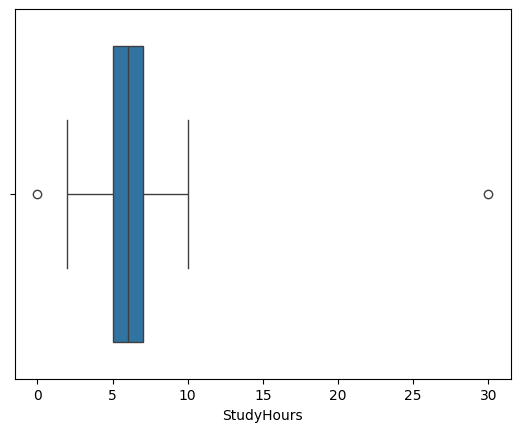

In [9]:
sns.boxplot(x=df['StudyHours'])

In [10]:
Q1 = df['StudyHours'].quantile(0.25)
Q3 = df['StudyHours'].quantile(0.75)
IQR = Q3 - Q1

df = df[(df['StudyHours'] >= Q1 - 1.5*IQR) & 
        (df['StudyHours'] <= Q3 + 1.5*IQR)]

<Axes: xlabel='SleepHours'>

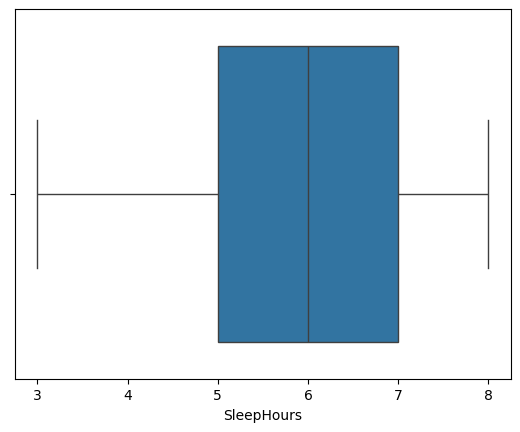

In [11]:
sns.boxplot(x=df['SleepHours'])

In [12]:
Q1 = df['SleepHours'].quantile(0.25)
Q3 = df['SleepHours'].quantile(0.75)
IQR = Q3 - Q1

df = df[(df['SleepHours'] >= Q1 - 1.5*IQR) & 
        (df['SleepHours'] <= Q3 + 1.5*IQR)]

<Axes: xlabel='ScreenTime'>

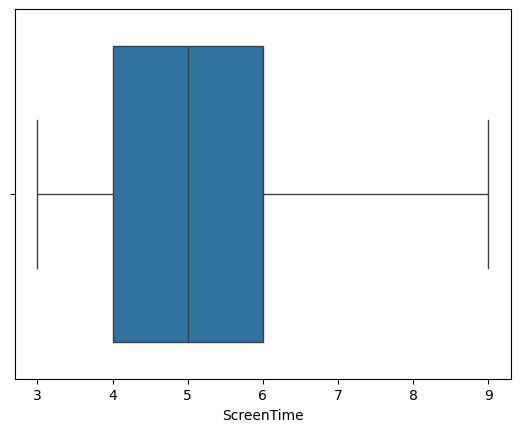

In [13]:
sns.boxplot(x=df['ScreenTime'])

In [14]:
Q1 = df['ScreenTime'].quantile(0.25)
Q3 = df['ScreenTime'].quantile(0.75)
IQR = Q3 - Q1

df = df[(df['ScreenTime'] >= Q1 - 1.5*IQR) & 
        (df['ScreenTime'] <= Q3 + 1.5*IQR)]

<Axes: xlabel='CaffeineCups'>

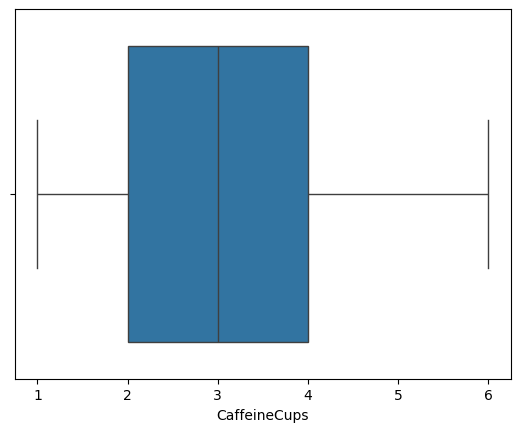

In [15]:
sns.boxplot(x=df['CaffeineCups'])

In [16]:
Q1 = df['CaffeineCups'].quantile(0.25)
Q3 = df['CaffeineCups'].quantile(0.75)
IQR = Q3 - Q1

df = df[(df['CaffeineCups'] >= Q1 - 1.5*IQR) & 
        (df['CaffeineCups'] <= Q3 + 1.5*IQR)]

<Axes: xlabel='StressLevel'>

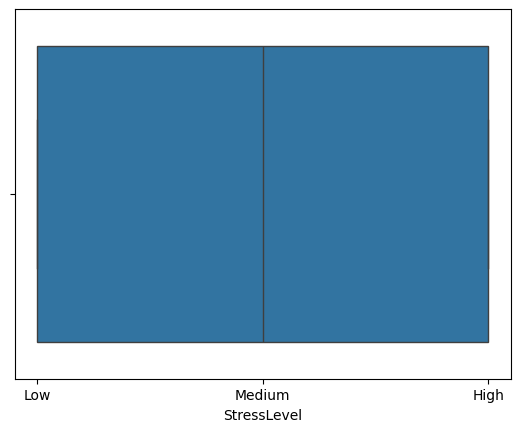

In [17]:
sns.boxplot(x=df['StressLevel'])

In [18]:
df['StudyHours'] = df['StudyHours'].fillna(df['StudyHours'].mean())

In [19]:
df['SleepHours'] = df['SleepHours'].fillna(df['SleepHours'].mean())

In [20]:
df['ScreenTime'] = df['ScreenTime'].fillna(df['ScreenTime'].mean())

In [21]:
df['CaffeineCups'] = df['CaffeineCups'].fillna(df['CaffeineCups'].mean())

In [22]:
df.isnull().sum()

ID              0
Age             0
StudyHours      0
SleepHours      0
ScreenTime      0
CaffeineCups    0
RandomNote      0
StressLevel     0
dtype: int64

In [23]:
cat_cols = ['RandomNote', 'StressLevel']

for col in cat_cols:
    labels = df[col].dropna().unique()
    mapping = {label: i for i, label in enumerate(labels)}
    df[col] = df[col].map(mapping)

,ID,Age,StudyHours,SleepHours,ScreenTime,CaffeineCups,RandomNote,StressLevel
ID,1.000000,0.142137,0.101416,-0.110576,0.062920,0.110576,0.982414,0.119513
Age,0.142137,1.000000,0.243894,-0.361169,0.322017,0.361169,0.190844,0.343581
StudyHours,0.101416,0.243894,1.000000,-0.948563,0.961583,0.948563,0.124676,0.856586
SleepHours,-0.110576,-0.361169,-0.948563,1.000000,-0.973450,-1.000000,-0.150846,-0.911310
ScreenTime,0.062920,0.322017,0.961583,-0.973450,1.000000,0.973450,0.086030,0.890971
CaffeineCups,0.110576,0.361169,0.948563,-1.000000,0.973450,1.000000,0.150846,0.911310
RandomNote,0.982414,0.190844,0.124676,-0.150846,0.086030,0.150846,1.000000,0.138520
StressLevel,0.119513,0.343581,0.856586,-0.911310,0.890971,0.911310,0.138520,1.000000


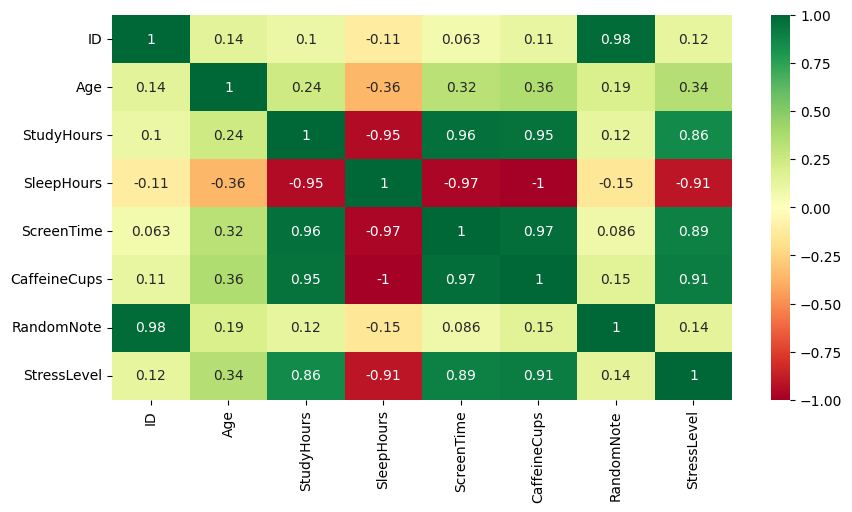

In [24]:
plt.figure(figsize=(10,5))
c= df.corr()
sns.heatmap(c, cmap="RdYlGn", annot=True)
c